# Track 2: Customer Segmentation & Behavioral RFM Clustering

## 1. Business Objective
Segment the Olist customer base using behavioral RFM (Recency, Frequency, Monetary) metrics combined with unsupervised clustering (K-Means). This segmentation empowers marketing, CRM, and customer success teams to deploy personalized campaigns, prevent churn, and optimize customer lifetime value (LTV).

---

## 2. Methodology Roadmap
- **Step 1:** Data Ingestion & Customer-Level RFM Aggregation
- **Step 2:** Distribution Audit & Log Transformation (Skewness Handling)
- **Step 3:** Feature Standardization (`StandardScaler`)
- **Step 4:** Optimal Cluster Detection (Elbow Curve & Silhouette Score)
- **Step 5:** K-Means Clustering & Segment Profiling
- **Step 6:** Business Interpretation & Marketing Action Rules
- **Step 7:** Save Segmented Dataset to `data/processed/`

## Step 1: Data Ingestion & Customer-Level RFM Aggregation
**Purpose:** Load the clean intermediate orders and customers datasets to calculate Recency (days since last purchase relative to snapshot date), Frequency (total unique orders per customer), and Monetary (total spend).

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load intermediate datasets
orders = pd.read_csv("../data/interim/clean_orders.csv")
customers = pd.read_csv("../data/raw/olist_customers_dataset.csv")
order_payments = pd.read_csv("../data/raw/olist_order_payments_dataset.csv")

# 2. Parse purchase timestamp
orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"])

# 3. Only keep delivered orders for true monetary/frequency accounting
delivered_orders = orders[orders["order_status"] == "delivered"].copy()

# 4. Calculate total payment value per order
order_spend = order_payments.groupby("order_id")["payment_value"].sum().reset_index()

# 5. Merge delivered orders with customer unique ID and order spend
df_rfm_raw = delivered_orders.merge(customers[["customer_id", "customer_unique_id"]], on="customer_id", how="inner")
df_rfm_raw = df_rfm_raw.merge(order_spend, on="order_id", how="inner")

# 6. Establish snapshot reference date (1 day after the latest purchase date in dataset)
snapshot_date = df_rfm_raw["order_purchase_timestamp"].max() + pd.Timedelta(days=1)
print(f"Dataset Snapshot Reference Date: {snapshot_date}")

# 7. Aggregate at customer_unique_id level
rfm_df = df_rfm_raw.groupby("customer_unique_id").agg(
    recency=("order_purchase_timestamp", lambda x: (snapshot_date - x.max()).days),
    frequency=("order_id", "nunique"),
    monetary=("payment_value", "sum")
).reset_index()

# Audit profile
print(f"Total Unique Customers Profiled: {len(rfm_df):,}")
display(rfm_df.describe().round(2))

Dataset Snapshot Reference Date: 2018-08-30 15:00:37
Total Unique Customers Profiled: 93,357


,recency,frequency,monetary
count,93357.00,93357.00,93357.00
mean,237.94,1.03,165.20
std,152.58,0.21,226.31
min,1.00,1.00,9.59
25%,114.00,1.00,63.06
50%,219.00,1.00,107.78
75%,346.00,1.00,182.56
max,695.00,15.00,13664.08


## Step 2: Distribution Audit & Log Transformation
**Purpose:** E-commerce RFM distributions are heavily right-skewed (especially Monetary and Frequency). We inspect distributions and apply logarithmic transformations ($\log(x + 1)$) to normalize variance before distance-based clustering.

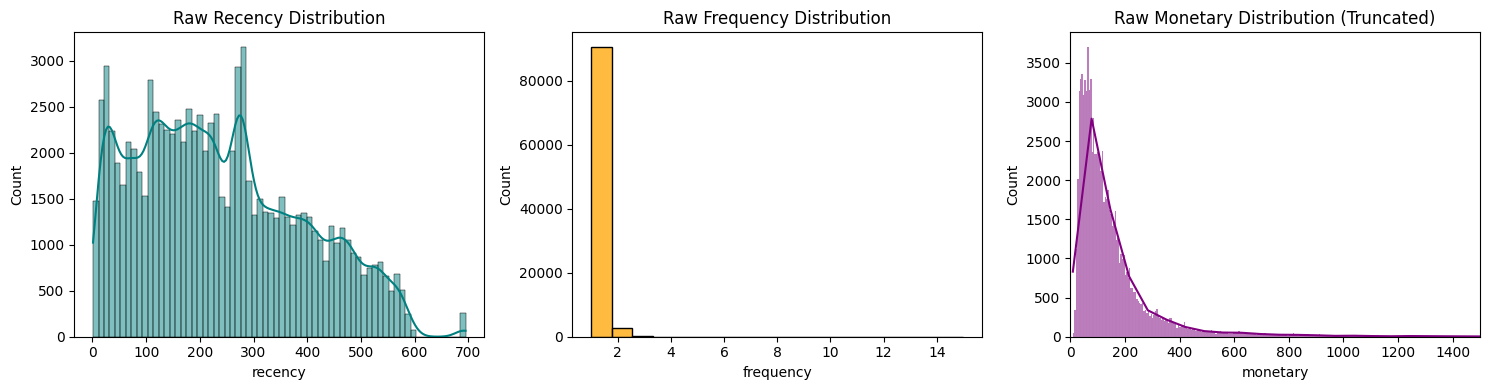

Raw Skewness:
recency       0.45
frequency    11.10
monetary      9.21
dtype: float64

Log-Transformed Skewness:
recency     -1.22
frequency    6.52
monetary     0.53
dtype: float64


In [3]:
# 1. Visualize raw distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(rfm_df["recency"], kde=True, ax=axes[0], color="teal")
axes[0].set_title("Raw Recency Distribution")

sns.histplot(rfm_df["frequency"], kde=False, ax=axes[1], color="orange")
axes[1].set_title("Raw Frequency Distribution")

sns.histplot(rfm_df["monetary"], kde=True, ax=axes[2], color="purple")
axes[2].set_title("Raw Monetary Distribution (Truncated)")
axes[2].set_xlim(0, 1500)
plt.tight_layout()
plt.show()

# 2. Check skewness values
print("Raw Skewness:")
print(rfm_df[["recency", "frequency", "monetary"]].skew().round(2))

# 3. Apply log(x + 1) transformation
rfm_log = rfm_df[["recency", "frequency", "monetary"]].copy()
rfm_log["recency"] = np.log1p(rfm_log["recency"])
rfm_log["frequency"] = np.log1p(rfm_log["frequency"])
rfm_log["monetary"] = np.log1p(rfm_log["monetary"])

print("\nLog-Transformed Skewness:")
print(rfm_log.skew().round(2))

## Step 3 & 4: Feature Scaling & Optimal Cluster Selection (Elbow & Silhouette)
**Purpose:** 
- Standardize the log-transformed RFM features using `StandardScaler` (zero mean, unit variance) so Euclidean distances are not dominated by monetary scale.
- Compute Inertia (Sum of Squared Distances) across cluster range $k \in [2, 7]$ to identify the Elbow point.
- Evaluate Silhouette Scores on a representative sample (10,000 customers) to measure cluster cohesion and separation.

k = 2 | Inertia = 190,212.0 | Silhouette Score = 0.7076
k = 3 | Inertia = 129,160.7 | Silhouette Score = 0.4206
k = 4 | Inertia = 82,895.7 | Silhouette Score = 0.3967
k = 5 | Inertia = 68,319.6 | Silhouette Score = 0.3563
k = 6 | Inertia = 58,426.0 | Silhouette Score = 0.3531
k = 7 | Inertia = 51,222.4 | Silhouette Score = 0.3515


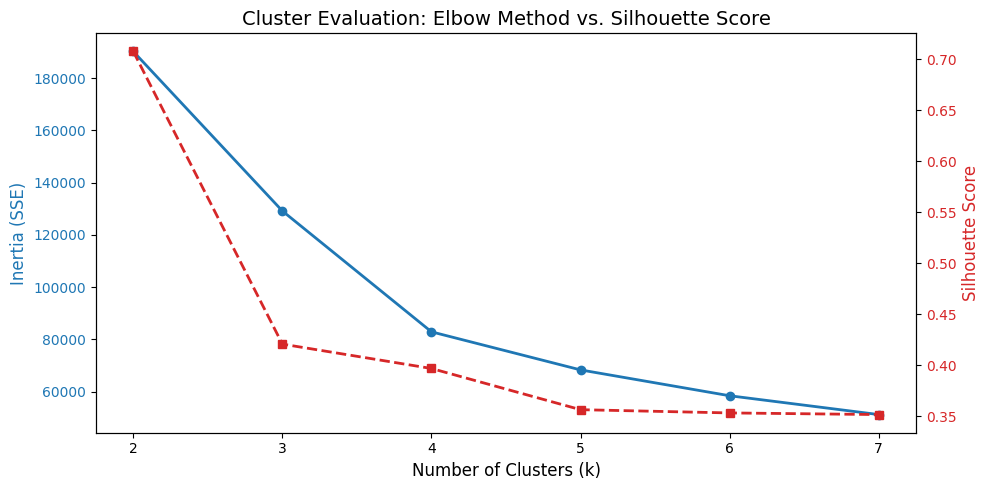

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# 1. Standardize log-transformed RFM features
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

# 2. Iterate through candidate k values
k_range = range(2, 8)
inertia_list = []
silhouette_list = []

# Take a stratified/random sample for fast silhouette calculation
sample_indices = np.random.RandomState(42).choice(len(rfm_scaled), size=10000, replace=False)
rfm_sample = rfm_scaled[sample_indices]

for k in k_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans_temp.fit_predict(rfm_scaled)
    
    inertia_list.append(kmeans_temp.inertia_)
    
    # Silhouette score on representative sample
    sil_score = silhouette_score(rfm_sample, cluster_labels[sample_indices])
    silhouette_list.append(sil_score)
    print(f"k = {k} | Inertia = {kmeans_temp.inertia_:,.1f} | Silhouette Score = {sil_score:.4f}")

# 3. Dual-plot: Elbow Method & Silhouette Scores
fig, ax1 = plt.subplots(figsize=(10, 5))

color = "tab:blue"
ax1.set_xlabel("Number of Clusters (k)", fontsize=12)
ax1.set_ylabel("Inertia (SSE)", color=color, fontsize=12)
ax1.plot(k_range, inertia_list, marker="o", color=color, linewidth=2, label="Inertia")
ax1.tick_params(axis="y", labelcolor=color)

ax2 = ax1.twinx()
color = "tab:red"
ax2.set_ylabel("Silhouette Score", color=color, fontsize=12)
ax2.plot(k_range, silhouette_list, marker="s", color=color, linestyle="--", linewidth=2, label="Silhouette")
ax2.tick_params(axis="y", labelcolor=color)

plt.title("Cluster Evaluation: Elbow Method vs. Silhouette Score", fontsize=14)
fig.tight_layout()
plt.show()

## Step 5: Final K-Means Model (k=4) & Behavioral Segment Profiling
**Purpose:** Fit the optimal K-Means model with $k=4$ on the standardized RFM features. Map cluster numbers to domain-meaningful business personas based on median Recency, Frequency, and Monetary metrics.

In [5]:
# 1. Fit final K-Means with k=4
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm_df["cluster"] = kmeans_final.fit_predict(rfm_scaled)

# 2. Inspect raw cluster statistical profiles (Median & Mean)
cluster_profile = rfm_df.groupby("cluster").agg(
    customer_count=("customer_unique_id", "count"),
    median_recency=("recency", "median"),
    median_frequency=("frequency", "median"),
    median_monetary=("monetary", "median"),
    mean_monetary=("monetary", "mean")
).reset_index()

cluster_profile["customer_share_%"] = (cluster_profile["customer_count"] / len(rfm_df) * 100).round(2)
display(cluster_profile.round(2))

,cluster,customer_count,median_recency,median_frequency,median_monetary,mean_monetary,customer_share_%
0,0,32185,255.0,1.0,199.31,295.78,34.48
1,1,42287,270.0,1.0,65.89,68.21,45.30
2,2,2801,199.0,2.0,225.55,308.59,3.00
3,3,16084,37.0,1.0,103.80,133.91,17.23


## Step 6: 2D/3D Cluster Visualizations
**Purpose:** Visualize behavioral separation across Recency, Frequency, and Monetary spend to validate cluster cohesion.

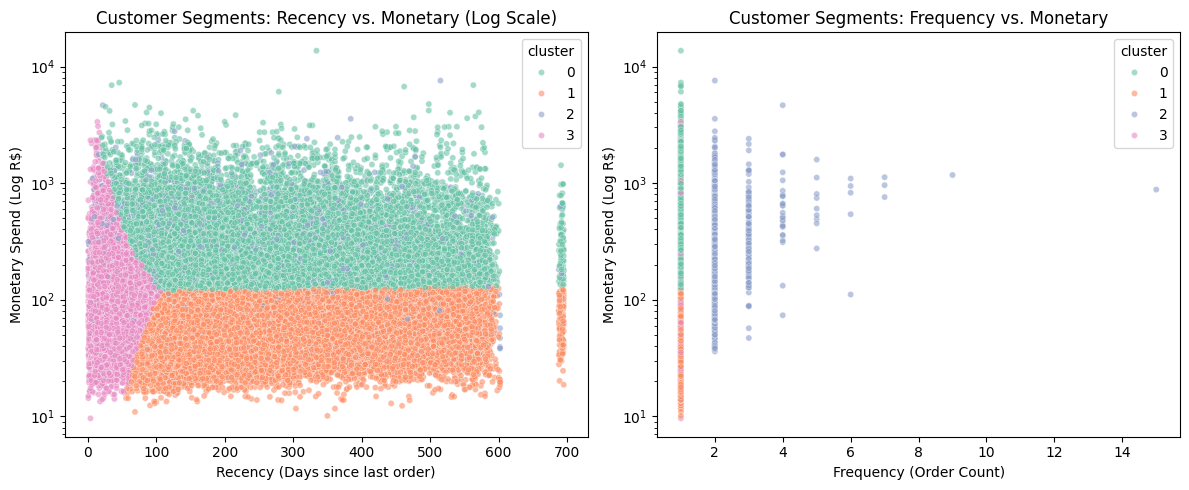

In [6]:
plt.figure(figsize=(12, 5))

# Plot 1: Recency vs Monetary (Log-scale)
plt.subplot(1, 2, 1)
sns.scatterplot(
    data=rfm_df, 
    x="recency", 
    y="monetary", 
    hue="cluster", 
    palette="Set2", 
    alpha=0.6,
    s=20
)
plt.yscale("log")
plt.title("Customer Segments: Recency vs. Monetary (Log Scale)", fontsize=12)
plt.xlabel("Recency (Days since last order)", fontsize=10)
plt.ylabel("Monetary Spend (Log R$)", fontsize=10)

# Plot 2: Frequency vs Monetary
plt.subplot(1, 2, 2)
sns.scatterplot(
    data=rfm_df, 
    x="frequency", 
    y="monetary", 
    hue="cluster", 
    palette="Set2", 
    alpha=0.6,
    s=20
)
plt.yscale("log")
plt.title("Customer Segments: Frequency vs. Monetary", fontsize=12)
plt.xlabel("Frequency (Order Count)", fontsize=10)
plt.ylabel("Monetary Spend (Log R$)", fontsize=10)

plt.tight_layout()
plt.show()

## Step 7: Persona Mapping & Segmented Dataset Export
**Purpose:** Map abstract cluster IDs (0, 1, 2, 3) to descriptive business personas and serialize the enriched customer dataset to `data/processed/customer_rfm_segments.csv` for downstream CRM, dashboard, and marketing activations.

In [7]:
import os

# 1. Map cluster integers to business personas
segment_map = {
    2: "Loyal Repeat Buyers",
    3: "Recent Fresh Buyers",
    0: "High-Value Dormant",
    1: "Low-Value Lost"
}

rfm_df["segment_name"] = rfm_df["cluster"].map(segment_map)

# 2. Segment-wise executive profile
final_segment_summary = rfm_df.groupby("segment_name").agg(
    customer_count=("customer_unique_id", "count"),
    median_recency_days=("recency", "median"),
    median_frequency=("frequency", "median"),
    median_monetary_spend=("monetary", "median"),
    mean_monetary_spend=("monetary", "mean")
).reset_index()

final_segment_summary["cohort_share_%"] = (final_segment_summary["customer_count"] / len(rfm_df) * 100).round(2)
display(final_segment_summary.round(2))

# 3. Export to processed data directory
os.makedirs("../data/processed", exist_ok=True)
export_path = "../data/processed/customer_rfm_segments.csv"
rfm_df.to_csv(export_path, index=False)
print(f"Segmented customer cohort saved to: {export_path}")

,segment_name,customer_count,median_recency_days,median_frequency,median_monetary_spend,mean_monetary_spend,cohort_share_%
0,High-Value Dormant,32185,255.0,1.0,199.31,295.78,34.48
1,Low-Value Lost,42287,270.0,1.0,65.89,68.21,45.30
2,Loyal Repeat Buyers,2801,199.0,2.0,225.55,308.59,3.00
3,Recent Fresh Buyers,16084,37.0,1.0,103.80,133.91,17.23


Segmented customer cohort saved to: ../data/processed/customer_rfm_segments.csv
